In [19]:
import pickle

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### Basin wise visualization

In [2]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [70]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [4]:
eval_results_path = Path("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p")

with open(eval_results_path, "rb") as f: 
    domain_metrics = pickle.load(f)

In [5]:
#load in training ids, to distinguish between learned and unseen (val, test) cell states 
with open("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/train_basin_ids.txt") as f: 
	train_ids_list = list(map(lambda x: int(x[:-1]),f.readlines())) 
	
for id in lamah_gdf.index: 
	
	if id in train_ids_list: 
		lamah_gdf.loc[id,"train_basin"] = True
	else: 
		lamah_gdf.loc[id, "train_basin"] = False

In [77]:
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

In [96]:

lamah_gdf[(lamah_gdf.period == "train")].NSE.describe()

count    686.000000
mean       0.785180
std        0.096875
min        0.080193
25%        0.740013
50%        0.807023
75%        0.849693
max        0.950725
Name: NSE, dtype: float64

In [ ]:

lamah_gdf[(lamah_gdf.strata == "transition") & (lamah_gdf.period == "validation")].NSE.describe()

count    31.000000
mean      0.609985
std       0.216485
min      -0.109243
25%       0.538961
50%       0.688733
75%       0.725982
max       0.845645
Name: NSE, dtype: float64

In [91]:
(lamah_gdf[(lamah_gdf.strata == "transition") & (lamah_gdf.period == "validation")].NSE < 0).sum()

1

<Axes: >

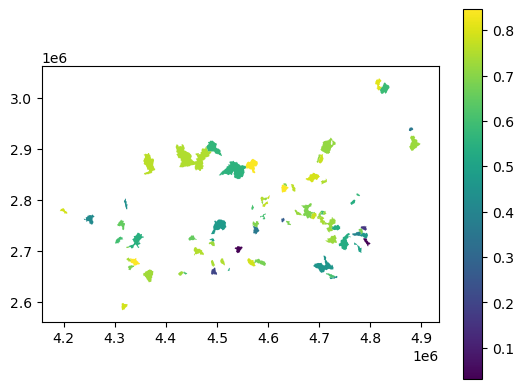

In [97]:
lamah_gdf[(lamah_gdf.NSE > 0) & (lamah_gdf.period == "validation")].plot(column="NSE", legend=True)

<Axes: >

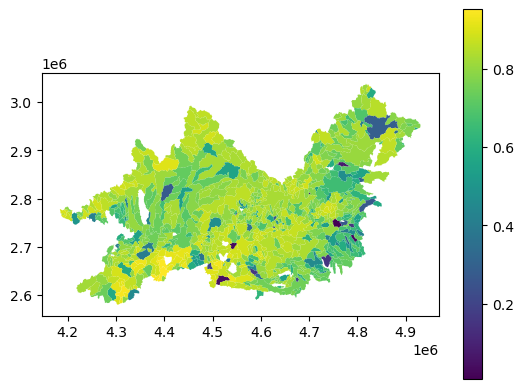

In [88]:
lamah_gdf[lamah_gdf.NSE>0].plot("NSE", legend=True)

### Tensorboard training history

In [13]:
tb_data_dir = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/tensorboard")
tb_files = list(tb_data_dir.glob("*.csv"))

tb_metrics_dict = {}

for file in tb_files: 

	with open(file, "r") as f: 	
		tb_metrics_dict[file.stem] = pd.read_csv(f)

In [23]:
tb_metrics_dict["valid_loss"]

,Wall time,Step,Value
0,1.773067e+09,1,0.062283
1,1.773070e+09,2,0.063693
2,1.773072e+09,3,0.066707
3,1.773075e+09,4,0.064813
4,1.773077e+09,5,0.062000
5,1.773080e+09,6,0.061252
6,1.773082e+09,7,0.060675
7,1.773085e+09,8,0.061517
8,1.773088e+09,9,0.059294
9,1.773090e+09,10,0.057514


Text(0.5, 0, 'Epoch')

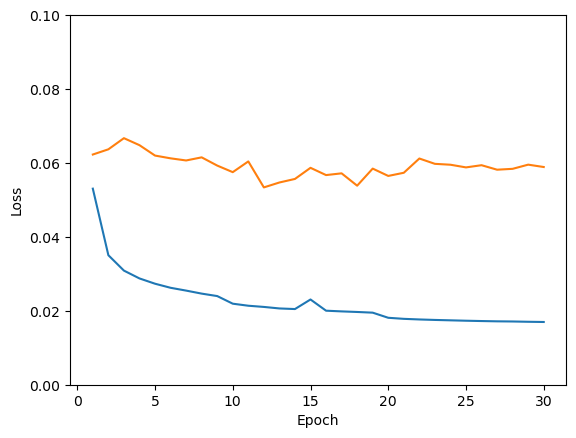

In [47]:
fig, ax = plt.subplots(1)

sns.lineplot(data=tb_metrics_dict["train_loss"], x="Step", y="Value", ax=ax)
sns.lineplot(data=tb_metrics_dict["valid_loss"], x="Step", y="Value", ax=ax)
ax.set_ylim(0,0.1)
ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")

(0.4, 1.0)

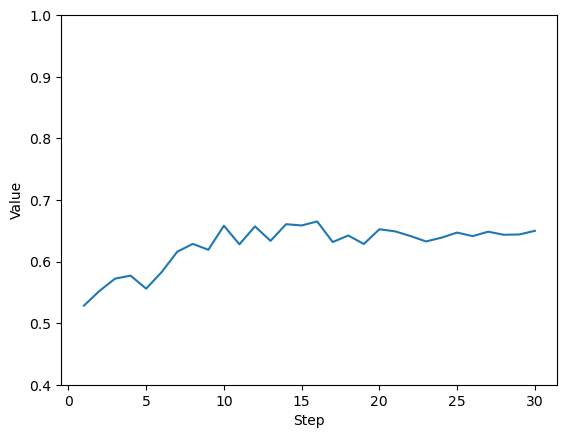

In [39]:
ax = plt.subplot()
sns.lineplot(data=tb_metrics_dict["median_nse"], x="Step", y="Value", ax=ax)
ax.set_ylim(0.4,1)